<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_score_based_diffusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Score-Based Diffusion Models

參考:
- Stanford CS236: Deep Generative Models I 2023
  - [Lecture 16 - Score Based Diffusion Models](https://www.youtube.com/watch?v=VsllsC2JMGY&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=17)
  - [Syllabus](https://deepgenerativemodels.github.io/syllabus.html)

#### Sampling as Iterative Denoising

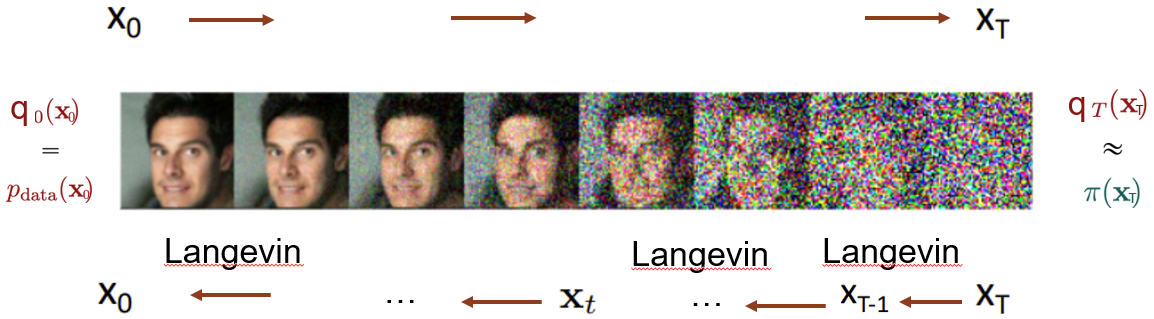

#### Iterative Noising Process

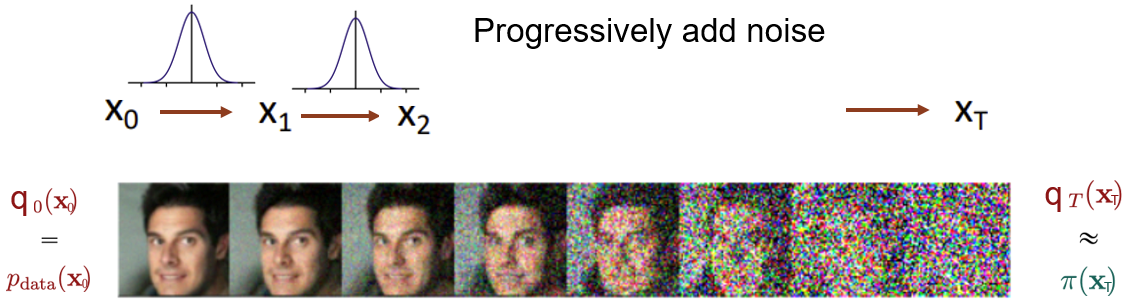

- $q(x_t \mid x_{t-1})=\mathcal{N}(x_t;\sqrt{1-\beta_t}x_{t-1},\beta_t I)$
- joint distribution $q(x_{1:T} \mid x_0)=\prod\limits_{t=1}^Tq(x_t \mid x_{t-1})$

$q(x_t \mid x_0)=\mathcal{N}(x_t;\sqrt{\bar{\alpha}_t}x_0,(1-\bar{\alpha}_t)I) \quad \text{where}\ \bar{\alpha}_t=\prod\limits_{s=1}^t(1-\beta_s)$
- Same as noise-perturbed data distributions in score-based models
- Efficient sampling at any $t$

some way of
basically mapping a data point to some
latent variable or or a vector of latent
variables through this very simple kind
of like procedure where you just add
noise to
it

#### Diffusion Perspective

there's some kind of process
that takes probability mass and then
diffuses it over the whole
space

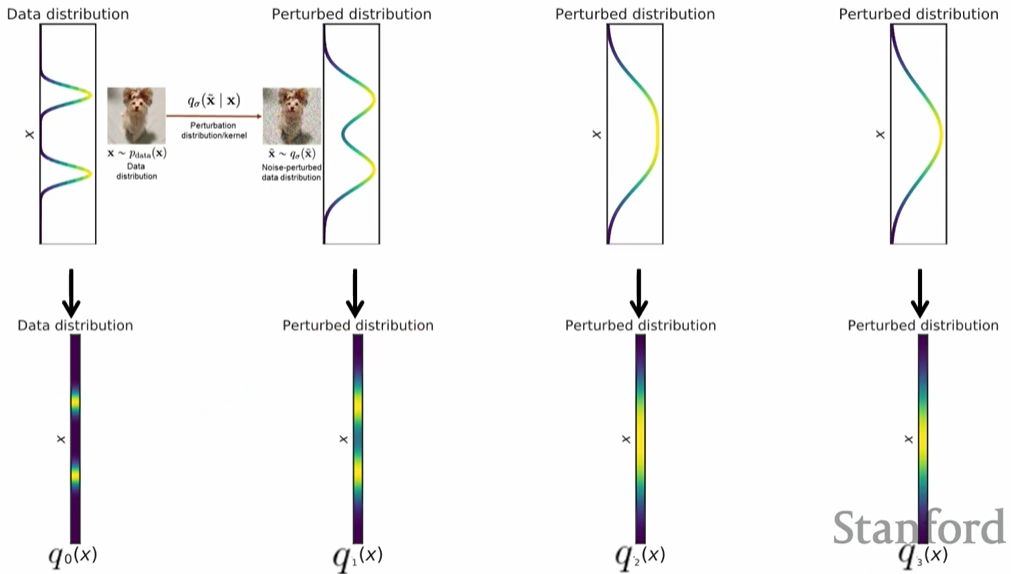

#### Iterative Denoising

- Issue: Exact denoising distribution is unknown!
- Solution: Learn a variational approximation

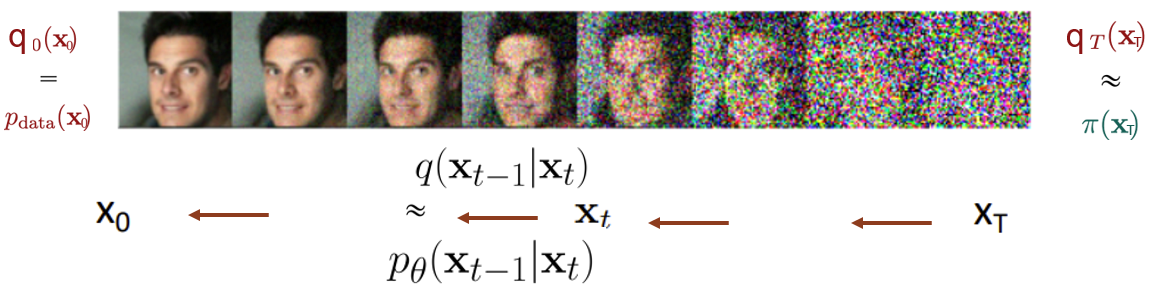

- Sample $x_T$ from $p(x_T)=\mathcal{N}(x_T;0,I)=\pi$
- Iteratively sample from $p_\theta(x_{t-1} \mid x_t)=\mathcal{N}(x_{t-1};\mu_\theta(x_t,t),\sigma_t^2I)$
- Joint distribution: $p_\theta(x_{0:T})=p(x_T)\prod\limits_{t=1}^T p_\theta(x_{t-1} \mid x_t)$

#### Diffusion Model as a Hierarchical VAE

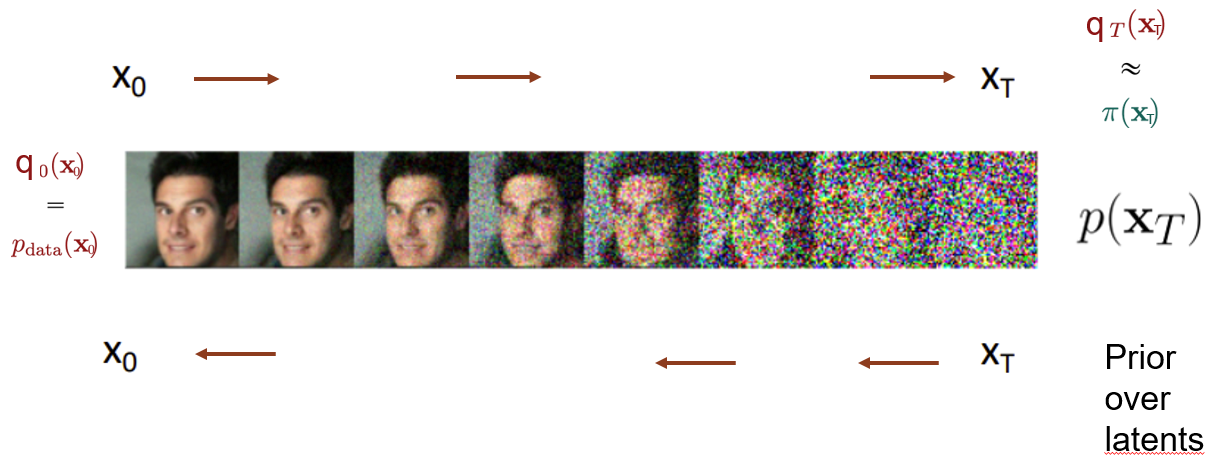

- Encoder (fixed): $q(x_{1:T} \mid x_0)=\prod\limits_{t=1}^Tq(x_t \mid x_{t-1})$
- Decoder (learnable): $p_\theta(x_{0:T})=p(x_T)\prod\limits_{t=1}^T p_\theta(x_{t-1} \mid x_t)$

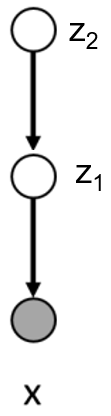

#### Diffusion Models as Score-Based Models

- Decoder parameterization: $\mu_\theta(x_t,t)=\frac{1}{1-\beta_t}\left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t,t) \right)$
  - Up to scaling, predict noise that was added and subtract it
- Loss: $L=\mathbb{E}_{x_0 \sim q(x_0),t \sim \mathcal{U}\{1,T\},\epsilon \sim \mathcal{N}(0,I)}\left[ \lambda_t \| \epsilon - \epsilon_\theta \left( \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon,t \right) \|_2^2 \right]$
  - ELBO loss reduces to denoising score matching!

Denoising Diffusion Probabilistic Model (DDPM)
- Training: Denoising score matching training
- Sampling: Iteratively Sample from decoders $p_\theta(x_{t-1 \mid x_t}))$ (Annealead Langevin Dynamics)

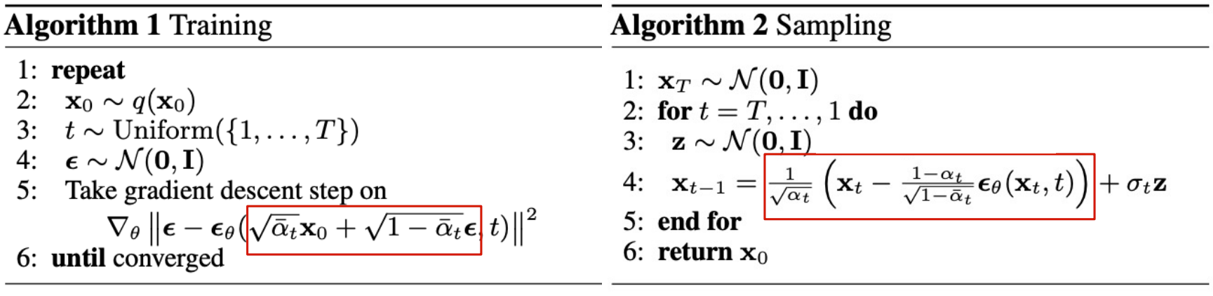

#### Architecture for the Denoiser

- Unet architecture (image-to-image) used in practice
- Same as the noise-condtional score network ($t$ represents the time index or equivalently the noise level)

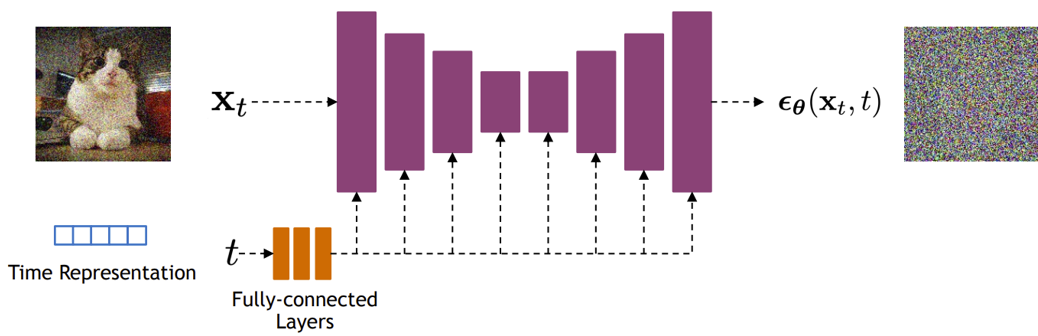

#### Accelerated Sampling

- Numerical methods + ODE formulation to accelerate sampling
- Denoising Diffusion Implicit Models (DDIM) [Song and Ermon, 2021]:
  - Coarsely discretize the time axis, take big steps
  - Corresponds to exponential integrator (semi-linear ODE) [Lu et al, 2022; Zhang and Chen, 2022]
  - 10x-50x speedups, comparable sample quality

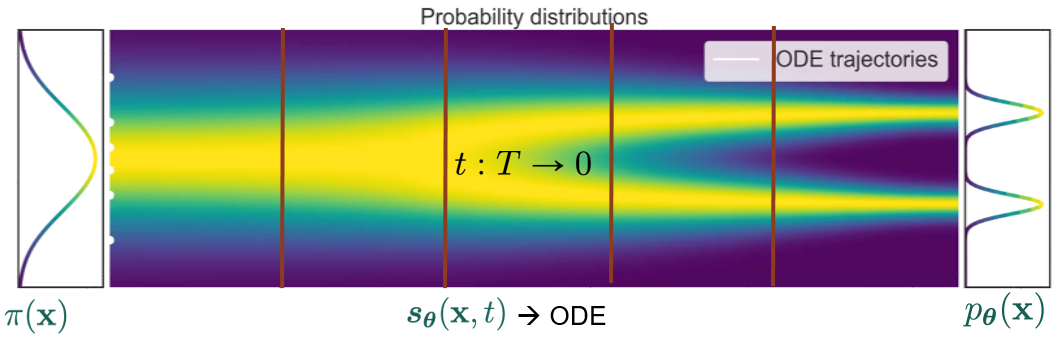

#### Distillation

- Progressive distillation [Salimans, Ho 2022]
  - DDIM sampler as a teacher model
  - Student model trained to do in 1 step what DDIM achieves in 2 steps
  - Applied recursively to drastically reduce the number of steps required

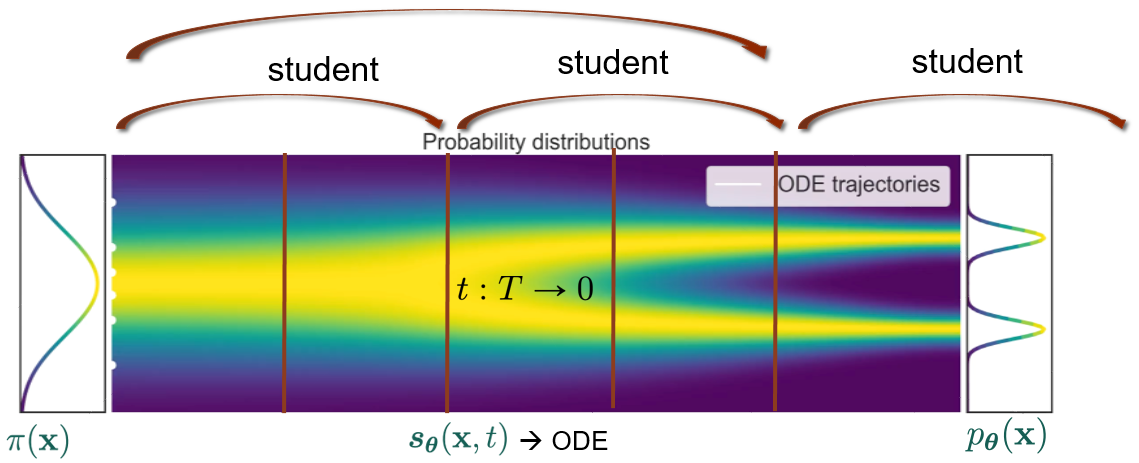

#### Latent Diffusion Model

- VAE mapping data to lower dimensional space
  - Faster
  - Can be applied to any data type (e.g. discrete)
- Diffusion model prior over the latent space of the autoencoder

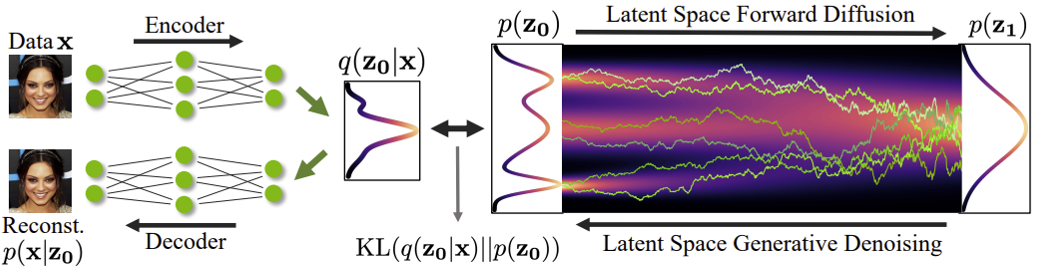

#### Stable Diffusion text2image Model

- Large scale, open source model, widely adopted
- distilled latent diffusion model
- Pre-trained, focus on reconstruction (autoencoder)
- Trained in the second stage, keeping initial autoencoder fixed

they really just care
about getting good reconstruction so
they don't care too much about uh the
distribution of the latent space to be
similar to a Gaussian they just care about
getting a good out encoder
essentially

it's not really necessary to
regularize